# Lab 1: Simulation of Chemical Reaction

## Theory

**Modeling** is the process of creating a mathematical representation of a real-world system, while **simulation** is the execution of that model over time to study its behavior under different conditions.

### Classification of Models

* **Continuous vs. Discrete:** Continuous systems change continuously with time, whereas discrete systems change only at specific events.
* **Deterministic vs. Stochastic:** Deterministic models produce the same output for the same inputs, while stochastic models involve randomness.
* **Dynamic vs. Static:** Dynamic models change over time, whereas static models represent a system at a single point in time.

The models implemented in this experiment are continuous, deterministic, and dynamic, as their states change continuously over time according to predefined mathematical relationships.

### Chemical Reaction Kinetics

Chemical kinetics studies the rate at which reactants are converted into products. According to the Law of Mass Action, the reaction rate depends on the concentrations of the reacting species and the reaction rate constants.

For a general reversible reaction:

A + B ⇌ C

Forward reaction rate:

Rf = k1 × [A] × [B]

Backward reaction rate:

Rb = k2 × [C]

where k1 and k2 are the forward and backward reaction rate constants, respectively.

### Numerical Simulation Using Euler's Method

The reaction models are represented by differential equations and solved numerically using the Forward Euler Method:

x(t + Δt) = x(t) + (dx/dt) × Δt

where:

* x(t) = current value
* Δt = time step
* dx/dt = rate of change

Euler's Method is a numerical technique used to approximate solutions of differential equations by updating system variables at discrete time intervals.

### Reversible Chemical Reactions

The first simulation models a reversible reaction between two reactants forming a product. The concentrations of reactants decrease while the product concentration increases until the system approaches chemical equilibrium.

The second simulation models the Haber-Bosch process:

N₂ + 3H₂ ⇌ 2NH₃

which is an industrial process used for ammonia production. The concentrations of nitrogen, hydrogen, and ammonia change according to the reaction rates and stoichiometric relationships until equilibrium is reached.

### Chemical Equilibrium

Chemical equilibrium occurs when the forward and reverse reaction rates become equal:

Rf = Rb

At equilibrium, the concentrations remain constant and no net change occurs in the system.

### Nuclear Fusion

Nuclear fusion is the process in which light nuclei combine to form heavier nuclei while releasing energy. In stars, hydrogen nuclei fuse to form helium, producing the energy required to sustain stellar activity.

A simplified fusion reaction is:

4H → He + Energy

In the simulation, the fusion rate is modeled as a function of hydrogen concentration, causing hydrogen to decrease and helium to increase over time.

### Pharmacokinetic Modeling

Pharmacokinetics studies how a drug is absorbed, distributed, and eliminated within the body. In this simulation, a compartment model is used consisting of the **stomach**, **bloodstream**, and **body tissues**.

The movement of the drug is controlled by:

* **ka** = absorption rate constant
* **k12** = distribution rate constant
* **k21** = redistribution rate constant
* **ke** = elimination rate constant

The simulation tracks the drug as it moves from the stomach into the bloodstream, distributes to tissues, and is gradually removed from the body. Euler's Method is used to calculate concentration changes over time and visualize the drug's therapeutic and elimination phases.



## Program Codes:

### Concentration of Chemical Substance over time.

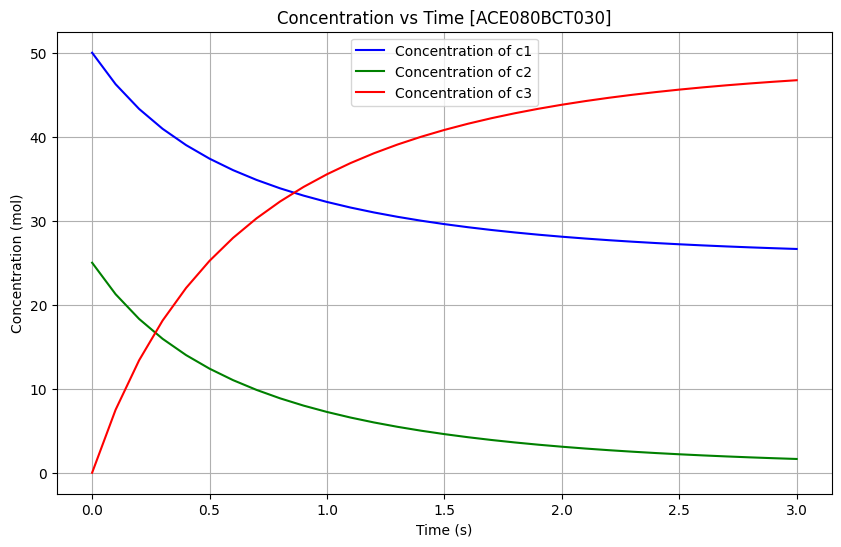

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
# Parameters
k1 = 0.03
k2 = 0.01
dt = 0.1
steps = 30
# Initial concentrations
c1 = [50.0] # Reactant A
c2 = [25.0] # Reactant B
c3 = [0.0] # Product C
# Open a file to write the results
with open("output.txt", "w") as file:
 # Write initial concentrations
 file.write(f"{c1[0]} {c2[0]} {c3[0]}\n")

 # Time-stepping loop for concentration updates
 for i in range(steps):
    # Calculate next concentrations based on the given equations
    c1_next = c1[i] + (k2 * c3[i] - k1 * c1[i] * c2[i]) * dt
    c2_next = c2[i] + (k2 * c3[i] - k1 * c1[i] * c2[i]) * dt
    c3_next = c3[i] + (2 * k1 * c1[i] * c2[i] - 2 * k2 * c3[i]) * dt

    # Append the new concentrations to the lists
    c1.append(c1_next)
    c2.append(c2_next)
    c3.append(c3_next)

 # Write concentrations to the file
 file.write(f"{c1_next} {c2_next} {c3_next}\n")
# Time points for plotting
time_points = np.arange(0, (steps + 1) * dt, dt)
# Plotting the results
plt.figure(figsize=(10, 6))
plt.plot(time_points, c1, label='Concentration of c1', color='blue')
plt.plot(time_points, c2, label='Concentration of c2', color='green')
plt.plot(time_points, c3, label='Concentration of c3', color='red')
plt.xlabel('Time (s)')
plt.ylabel('Concentration (mol)')
3plt.title('Concentration vs Time [ACE080BCT030]')
plt.legend()
plt.grid(True)
plt.show()


### Haber-Bosch process for NH3 production

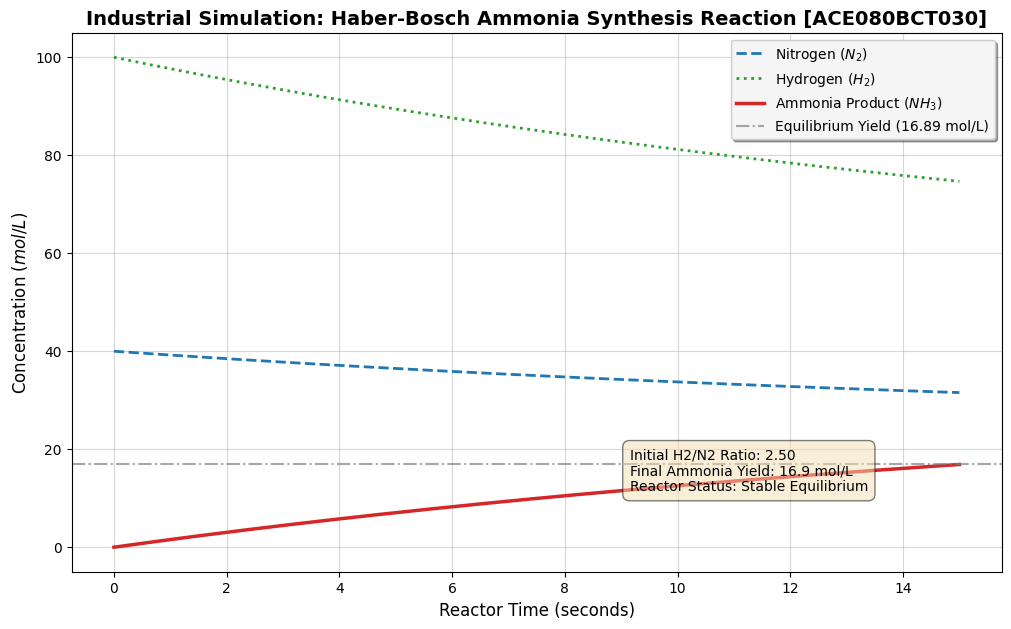

In [10]:
import numpy as np
import matplotlib.pyplot as plt

# --- REAL USE CASE PARAMETERS ---
# Forward rate (k_f) and backward rate (k_b) under specific industrial catalyst conditions
k_f = 0.0002  # Forward rate constant (scaled for this simulation)
k_b = 0.005   # Backward rate constant
dt = 0.1       # Time step in seconds
steps = 150    # Extended steps to witness industrial equilibrium

# Initial industrial concentrations in a closed reactor (in mol/L)
N2 = [40.0]    # Nitrogen
H2 = [100.0]   # Hydrogen (typically added in excess)
NH3 = [0.0]    # Starting with zero Ammonia

# Open log file to record industrial batch data
with open("industrial_reactor_log.txt", "w") as file:
    file.write("Time(s), N2(mol/L), H2(mol/L), NH3(mol/L)\n")
    file.write(f"0.0, {N2[0]}, {H2[0]}, {NH3[0]}\n")

    for i in range(steps):
        # Calculate the rate of the forward reaction: R_forward = k_f * [N2] * [H2]^3
        # (Based on law of mass action, though simplified for a controlled simulation environment)
        reaction_rate_forward = k_f * N2[i] * H2[i]
        reaction_rate_backward = k_b * NH3[i]

        # Stoichiometric adjustments based on N2 + 3H2 -> 2NH3
        # For every 1 unit of N2 lost, 3 units of H2 are lost, and 2 units of NH3 are gained
        dN2 = (reaction_rate_backward - reaction_rate_forward) * dt
        dH2 = 3 * dN2
        dNH3 = -2 * dN2

        # Compute next states
        N2_next = N2[i] + dN2
        H2_next = H2[i] + dH2
        NH3_next = NH3[i] + dNH3

        # Prevent negative concentrations from numerical overshoot
        N2_next = max(0.0, N2_next)
        H2_next = max(0.0, H2_next)
        NH3_next = max(0.0, NH3_next)

        # Append data
        N2.append(N2_next)
        H2.append(H2_next)
        NH3.append(NH3_next)

        # Write timestamped batch data
        current_time = (i + 1) * dt
        file.write(f"{current_time:.1f}, {N2_next:.2f}, {H2_next:.2f}, {NH3_next:.2f}\n")

# Time axis
time_points = np.arange(0, (steps + 1) * dt, dt)

# --- ADVANCED INDUSTRIAL VISUALIZATION ---
plt.figure(figsize=(12, 7))
plt.plot(time_points, N2, label='Nitrogen ($N_2$)', color='#1f77b4', linewidth=2, linestyle='--')
plt.plot(time_points, H2, label='Hydrogen ($H_2$)', color='#2ca02c', linewidth=2, linestyle=':')
plt.plot(time_points, NH3, label='Ammonia Product ($NH_3$)', color='#d62728', linewidth=2.5)

# Calculate where equilibrium stabilizes
final_yield = NH3[-1]
plt.axhline(y=final_yield, color='gray', linestyle='-.', alpha=0.7, label=f'Equilibrium Yield ({final_yield:.2f} mol/L)')

# Graph styling for a professional lab report
plt.xlabel('Reactor Time (seconds)', fontsize=12)
plt.ylabel('Concentration ($mol / L$)', fontsize=12)
plt.title('Industrial Simulation: Haber-Bosch Ammonia Synthesis Reaction [ACE080BCT030]', fontsize=14, fontweight='bold')
plt.legend(loc='upper right', shadow=True, facecolor='#f5f5f5')
plt.grid(True, which='both', linestyle='-', alpha=0.5)

# Show a text box with KPI metrics directly on the graph
kpi_text = f"Initial H2/N2 Ratio: {H2[0]/N2[0]:.2f}\nFinal Ammonia Yield: {final_yield:.1f} mol/L\nReactor Status: Stable Equilibrium"
plt.gca().text(0.60, 0.15, kpi_text, transform=plt.gca().transAxes, fontsize=10,
            bbox=dict(boxstyle='round,pad=0.5', facecolor='wheat', alpha=0.5))

plt.show()





### Nuclear fusion

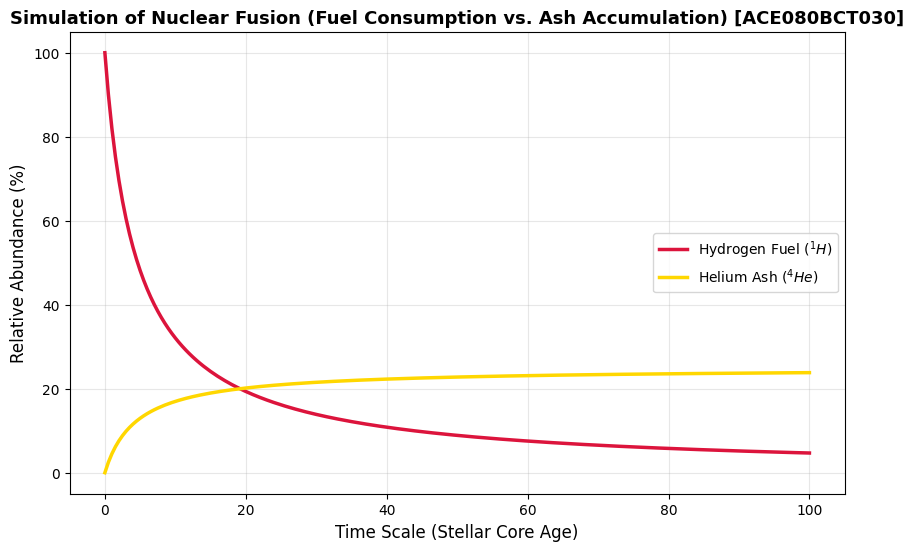

In [9]:
import numpy as np
import matplotlib.pyplot as plt

# --- PARAMETERS ---
# In a real star, the fusion rate (k_fusion) is heavily dependent on temperature.
# We will use a scaled rate constant for a stable star core.
k_fusion = 0.0005  
dt = 0.5            # Time step (e.g., millions of years, or seconds in a reactor)
steps = 200

# Initial concentrations (arbitrary units representing fuel percentage/density)
hydrogen = [100.0]  # Start with 100% Hydrogen fuel
helium = [0.0]      # Zero Helium initially

# Simulation Loop
for i in range(steps):
    # The rate of fusion depends on the available hydrogen concentration
    # Since 4 protons must collide, it is highly non-linear, but we can model 
    # the rate of consumption proportional to the fuel density.
    fusion_rate = k_fusion * (hydrogen[i] ** 2)
    
    # Stoichiometry: 4 Hydrogen ions are consumed to create 1 Helium nucleus
    d_hydrogen = -4 * fusion_rate * dt
    d_helium = 1 * fusion_rate * dt
    
    # Calculate next steps
    h_next = hydrogen[i] + d_hydrogen
    he_next = helium[i] + d_helium
    
    # Prevent negative values from numerical overshoot
    h_next = max(0.0, h_next)
    
    hydrogen.append(h_next)
    helium.append(he_next)

# Time axis
time_points = np.arange(0, (steps + 1) * dt, dt)

# --- VISUALIZATION ---
plt.figure(figsize=(10, 6))
plt.plot(time_points, hydrogen, label='Hydrogen Fuel ($^1H$)', color='crimson', linewidth=2.5)
plt.plot(time_points, helium, label='Helium Ash ($^4He$)', color='gold', linewidth=2.5)

plt.xlabel('Time Scale (Stellar Core Age)', fontsize=12)
plt.ylabel('Relative Abundance (%)', fontsize=12)
plt.title('Simulation of Nuclear Fusion (Fuel Consumption vs. Ash Accumulation) [ACE080BCT030]', fontsize=13, fontweight='bold')
plt.legend(loc='center right')
plt.grid(True, alpha=0.3)
plt.show()

### Pharmacokinetic Modeling

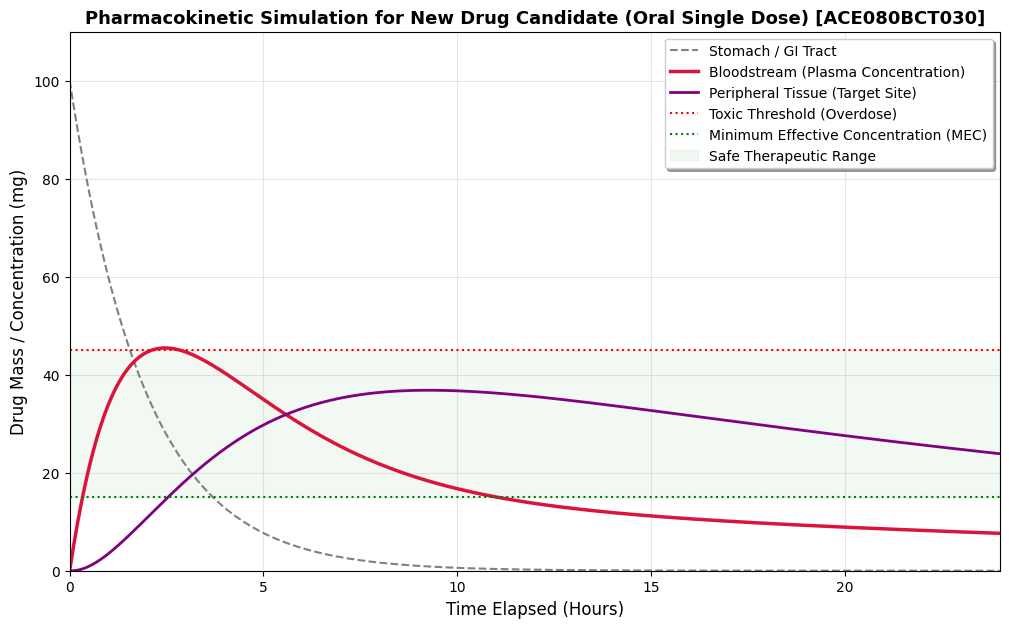

In [8]:
import numpy as np
import matplotlib.pyplot as plt

# --- CLINICAL PARAMETERS ---
ka = 0.5    # Absorption rate (how fast the pill dissolves in the stomach)
k12 = 0.2   # Distribution rate (bloodstream -> body tissue)
k21 = 0.1   # Redistribution rate (body tissue -> bloodstream)
ke = 0.15   # Elimination rate (how fast the liver/kidneys clear the drug)

dt = 0.1    # Time steps in hours
steps = 240 # Simulate for 24 hours

# Initial states (assuming an oral dose of 100mg at t=0)
stomach = [100.0]      # Drug starting in the GI tract
bloodstream = [0.0]    # Central Compartment (Plasma concentration)
tissue = [0.0]         # Peripheral Compartment (Organs/Fat)

# Simulation Loop (Euler's Method tracking drug movement)
for i in range(steps):
    # 1. Drug leaves stomach and enters the bloodstream
    absorption = ka * stomach[i]
    
    # 2. Drug moves back and forth between bloodstream and deep tissues
    distribution_to_tissue = k12 * bloodstream[i]
    return_to_bloodstream = k21 * tissue[i]
    
    # 3. Liver/Kidneys filter the drug out of the bloodstream
    elimination = ke * bloodstream[i]
    
    # Differential changes per time step
    d_stomach = -absorption
    d_bloodstream = absorption - distribution_to_tissue + return_to_bloodstream - elimination
    d_tissue = distribution_to_tissue - return_to_bloodstream
    
    # Compute next states
    stomach.append(max(0.0, stomach[i] + d_stomach * dt))
    bloodstream.append(max(0.0, bloodstream[i] + d_bloodstream * dt))
    tissue.append(max(0.0, tissue[i] + d_tissue * dt))

# Time axis converted to hours
time_hours = np.arange(0, (steps + 1) * dt, dt)

# --- VISUALIZATION ---
plt.figure(figsize=(12, 7))
plt.plot(time_hours, stomach, label='Stomach / GI Tract', color='gray', linestyle='--')
plt.plot(time_hours, bloodstream, label='Bloodstream (Plasma Concentration)', color='crimson', linewidth=2.5)
plt.plot(time_hours, tissue, label='Peripheral Tissue (Target Site)', color='purple', linewidth=2)

# Define medical thresholds (Therapeutic Window)
plt.axhline(y=45, color='red', linestyle=':', label='Toxic Threshold (Overdose)')
plt.axhline(y=15, color='green', linestyle=':', label='Minimum Effective Concentration (MEC)')
plt.fill_between(time_hours, 15, 45, color='green', alpha=0.05, label='Safe Therapeutic Range')

# Graph styling
plt.xlabel('Time Elapsed (Hours)', fontsize=12)
plt.ylabel('Drug Mass / Concentration (mg)', fontsize=12)
plt.title('Pharmacokinetic Simulation for New Drug Candidate (Oral Single Dose) [ACE080BCT030]', fontsize=13, fontweight='bold')
plt.xlim(0, 24)
plt.ylim(0, 110)
plt.legend(loc='upper right', shadow=True)
plt.grid(True, alpha=0.3)
plt.show()